# Load labels and inspect dataset
Before training any model, we need to understand what data we're working with. Here we load a CSV file (labels.csv) that maps each video frame filename to its corresponding moisture level. Key things to check: total frame count, unique moisture levels (are they continuous or a small set of discrete classes?), and a sample of rows to confirm filenames and labels look correct.

In [1]:
import os
import pandas as pd
from fastai.vision.all import *

df = pd.read_csv("labels.csv")
print(f"Total frames: {len(df)}")
print(f"Moisture levels: {df['moisture'].unique()}")
print(df.head(10))

Total frames: 1775
Moisture levels: [ 0  1 12 14 16  2  4]
                   filename  moisture
0  0%_cropped_frame0000.jpg         0
1  0%_cropped_frame0001.jpg         0
2  0%_cropped_frame0002.jpg         0
3  0%_cropped_frame0003.jpg         0
4  0%_cropped_frame0004.jpg         0
5  0%_cropped_frame0005.jpg         0
6  0%_cropped_frame0006.jpg         0
7  0%_cropped_frame0007.jpg         0
8  0%_cropped_frame0008.jpg         0
9  0%_cropped_frame0009.jpg         0


# Build the DataLoaders and Find the Learning Rate
Construct a fastai DataLoaders object, which handles loading images, applying transforms, and splitting into train/validation sets. 
y_block=RegressionBlock tells fastai we're predicting a continuous number rather than a category.
lr_find() to plot loss vs. learning rate and identify the best value to use before committing to full training.

c:\Users\nikko\.conda\envs\regression\lib\site-packages\fastai\data\transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
c:\Users\nikko\.conda\envs\regression\lib\site-packages\fastai\data\transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\nikko/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:59<00:00, 1.47MB/s]


<div></div>

c:\Users\nikko\.conda\envs\regression\lib\site-packages\fastai\data\transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


SuggestedLRs(valley=0.001737800776027143)

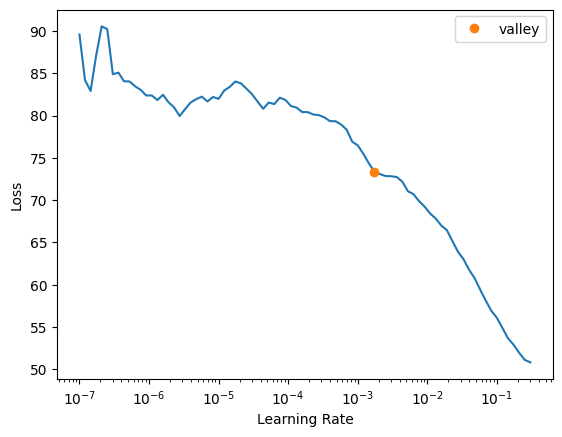

In [2]:
df = pd.read_csv("labels.csv")

dls = ImageDataLoaders.from_df(
    df,
    path="frames/",
    label_col="moisture",
    y_block=RegressionBlock,
    item_tfms=Resize(224),
    valid_pct=0.2          # uses 20% of frames for testing
)

learn = vision_learner(dls, resnet34, loss_func=MSELossFlat())
# learn.fine_tune(30)
# Find best learning rate first
learn.lr_find()

# Train
fastai's transfer learning loop. It takes a ResNet34 pretrained on ImageNet and adapts it to our moisture task

In [ ]:
learn.fine_tune(30, base_lr=1e-3)

epoch,train_loss,valid_loss,time
0,1.314413,0.041007,01:40


c:\Users\nikko\.conda\envs\regression\lib\site-packages\fastai\data\transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


epoch,train_loss,valid_loss,time
0,1.270080,0.144116,01:54
1,1.291196,0.059382,01:55
2,1.224813,0.124476,01:55
3,1.249253,0.056817,01:54
4,1.180362,0.048066,01:54
5,1.184602,0.111842,01:55
6,1.204543,0.084609,01:55
7,1.278200,0.034361,01:55
8,1.270010,0.092699,01:54
9,1.372510,0.070449,01:55


In [5]:
learn.save('0309model')

Path('frames/models/0309model.pth')

# Evaluate Predictions
get_preds() runs the model over the validation set and returns predictions alongside ground truth.

In [7]:
preds, targets = learn.get_preds(with_input=False)

for i in range(10):
    predicted = preds[i].item()
    actual = targets[i].item()
    print(f"Predicted: {predicted:.1f}%  |  Actual: {actual:.1f}%  |  Error: {abs(predicted-actual):.1f}%")

<div><progress max="6" value="0"></progress> 0.00% [0/6 00:00&lt;?]</div>

Predicted: 4.1%  |  Actual: 4.0%  |  Error: 0.1%
Predicted: 1.1%  |  Actual: 1.0%  |  Error: 0.1%
Predicted: 1.1%  |  Actual: 1.0%  |  Error: 0.1%
Predicted: 3.9%  |  Actual: 4.0%  |  Error: 0.1%
Predicted: 15.5%  |  Actual: 16.0%  |  Error: 0.5%
Predicted: 4.1%  |  Actual: 4.0%  |  Error: 0.1%
Predicted: 1.0%  |  Actual: 1.0%  |  Error: 0.0%
Predicted: 15.7%  |  Actual: 16.0%  |  Error: 0.3%
Predicted: 12.0%  |  Actual: 12.0%  |  Error: 0.0%
Predicted: 13.7%  |  Actual: 14.0%  |  Error: 0.3%
